In [1]:
import novae
import scanpy as sc
import warnings
warnings.filterwarnings("ignore")
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../", "utils")))
import spatial_utils

In [3]:
ad = sc.read_h5ad('/Users/christoffer/work/karolinska/development/oligo-mtDSB/data/mtDNA_DSB_5k_clustered_annotation_with_rbd_2_cytetype.h5ad')


In [4]:
ad

AnnData object with n_obs × n_vars = 980474 × 5101
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'n_genes_by_counts', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_2', 'cell_class', 'sample_id', 'age', 'sex', 'genotype', 'condition', 'cell_type', 'cell_id', 'rbd_domain_0.1', 'rbd_domain_0.2', 'rbd_domain_0.5', 'rbd_domain_1.0', 'RBD_compartment', 'RBD_compartment_simplified', 'leiden_1.5', 'leiden_2.1', 'leiden_2.3', 'leiden_2.5', 'leiden_3', 'cytetype_annotation_leiden_3', 'cytetype_cellOntologyTerm_leiden_3'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'gene_symbols'
    uns: 'cytetype_annotation_leiden_3_colors', 'cytetype_jobDetails', 'cytetype_results', 'rank_genes_groups'
    obsm: 'X_pca', '

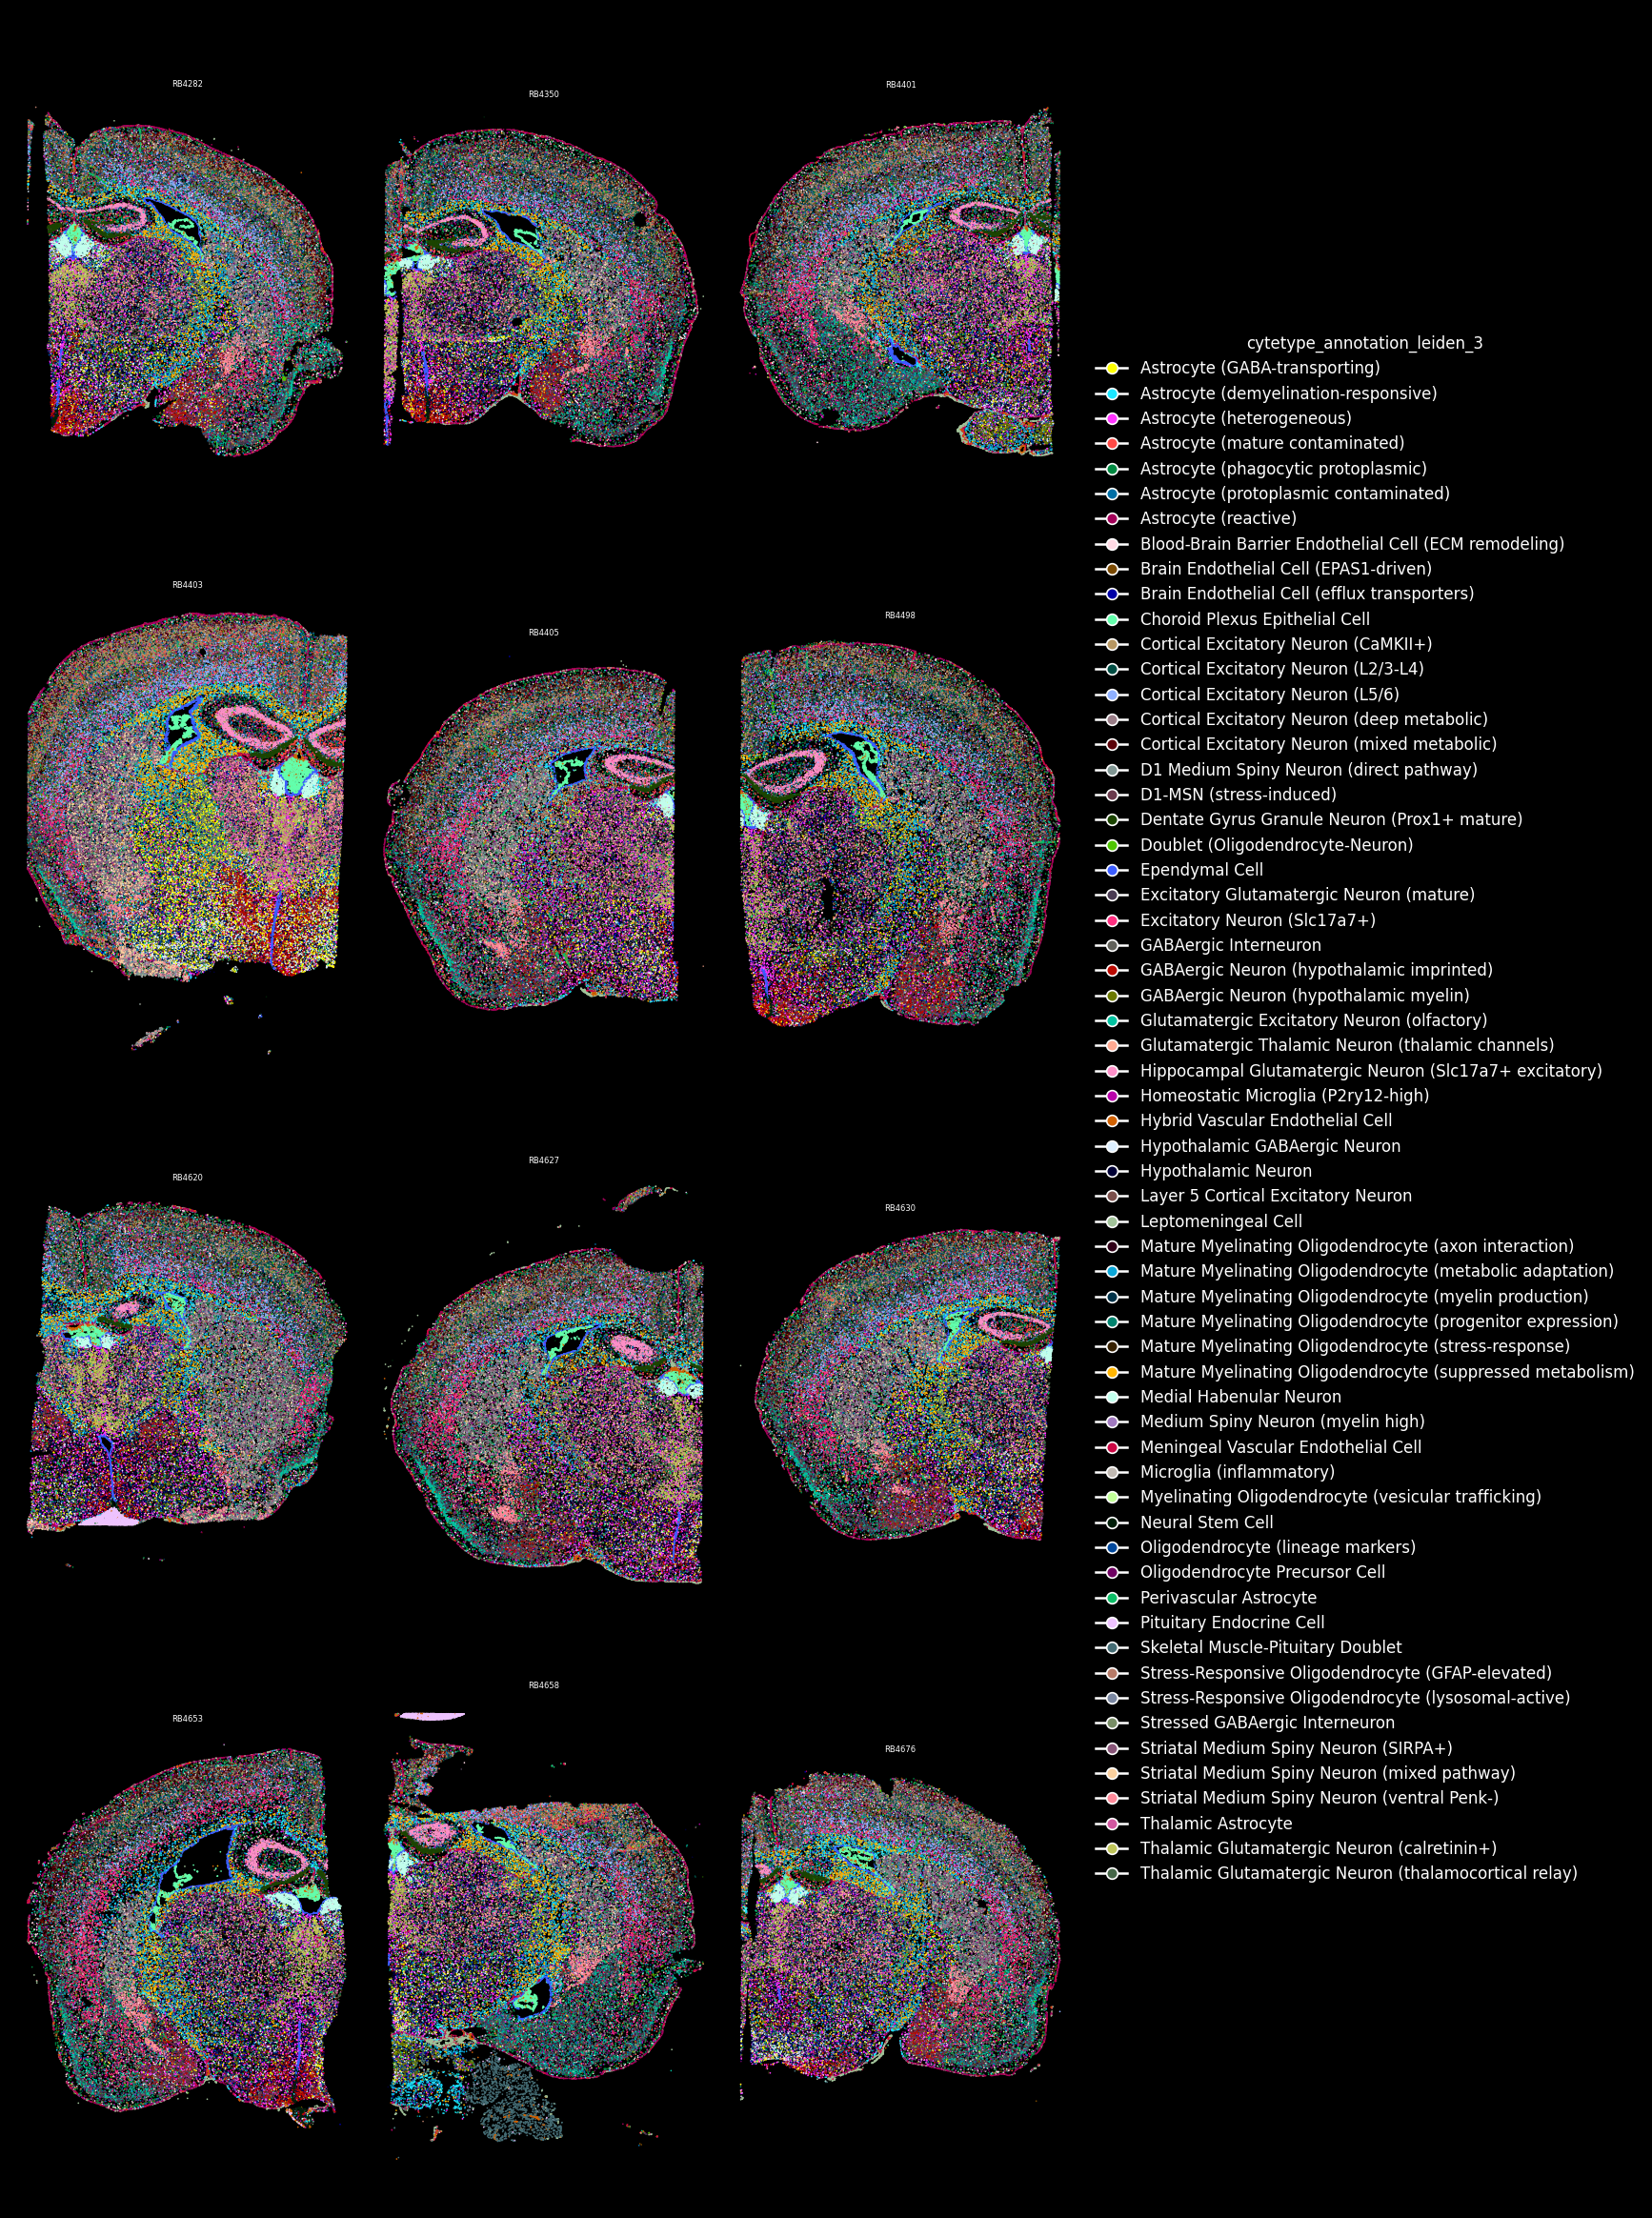

In [8]:
# usage
spatial_utils.plot_spatial_compact_fast(
    ad,
    color="cytetype_annotation_leiden_3",
    groupby="sample_id",
    spot_size=1,
    cols=3,
    height=20,
    legend_col_width=1.0,
    background="black",
    grey_alpha=0.05,invert_y = False

)

In [9]:
ad.X = ad.layers['counts']

In [10]:
model = novae.Novae.from_pretrained("MICS-Lab/novae-mouse-0")
model

Novae model
   ├── Known genes: 60697
   ├── Parameters: 32.1M
   ├── Model name: MICS-Lab/novae-mouse-0
   ├── Trained: True
   └── Multimodal: False

In [11]:
novae.spatial_neighbors(ad, slide_key="sample_id", radius =80, )

[INFO] (novae.utils.build) Computing graph on 980,474 cells (coord_type=generic, delaunay=True, radius=[0.0, 80.0], n_neighs=None)


In [12]:
#model.fine_tune(
#    [ad_cell_sub, ad_sub],
#    accelerator="cpu",
#)

In [15]:
model.compute_representations(ad, zero_shot = True)


Computing representations:   0%|          | 0/1915 [00:00<?, ?it/s]

In [16]:
model.assign_domains(ad, level = 15)

'novae_domains_15'

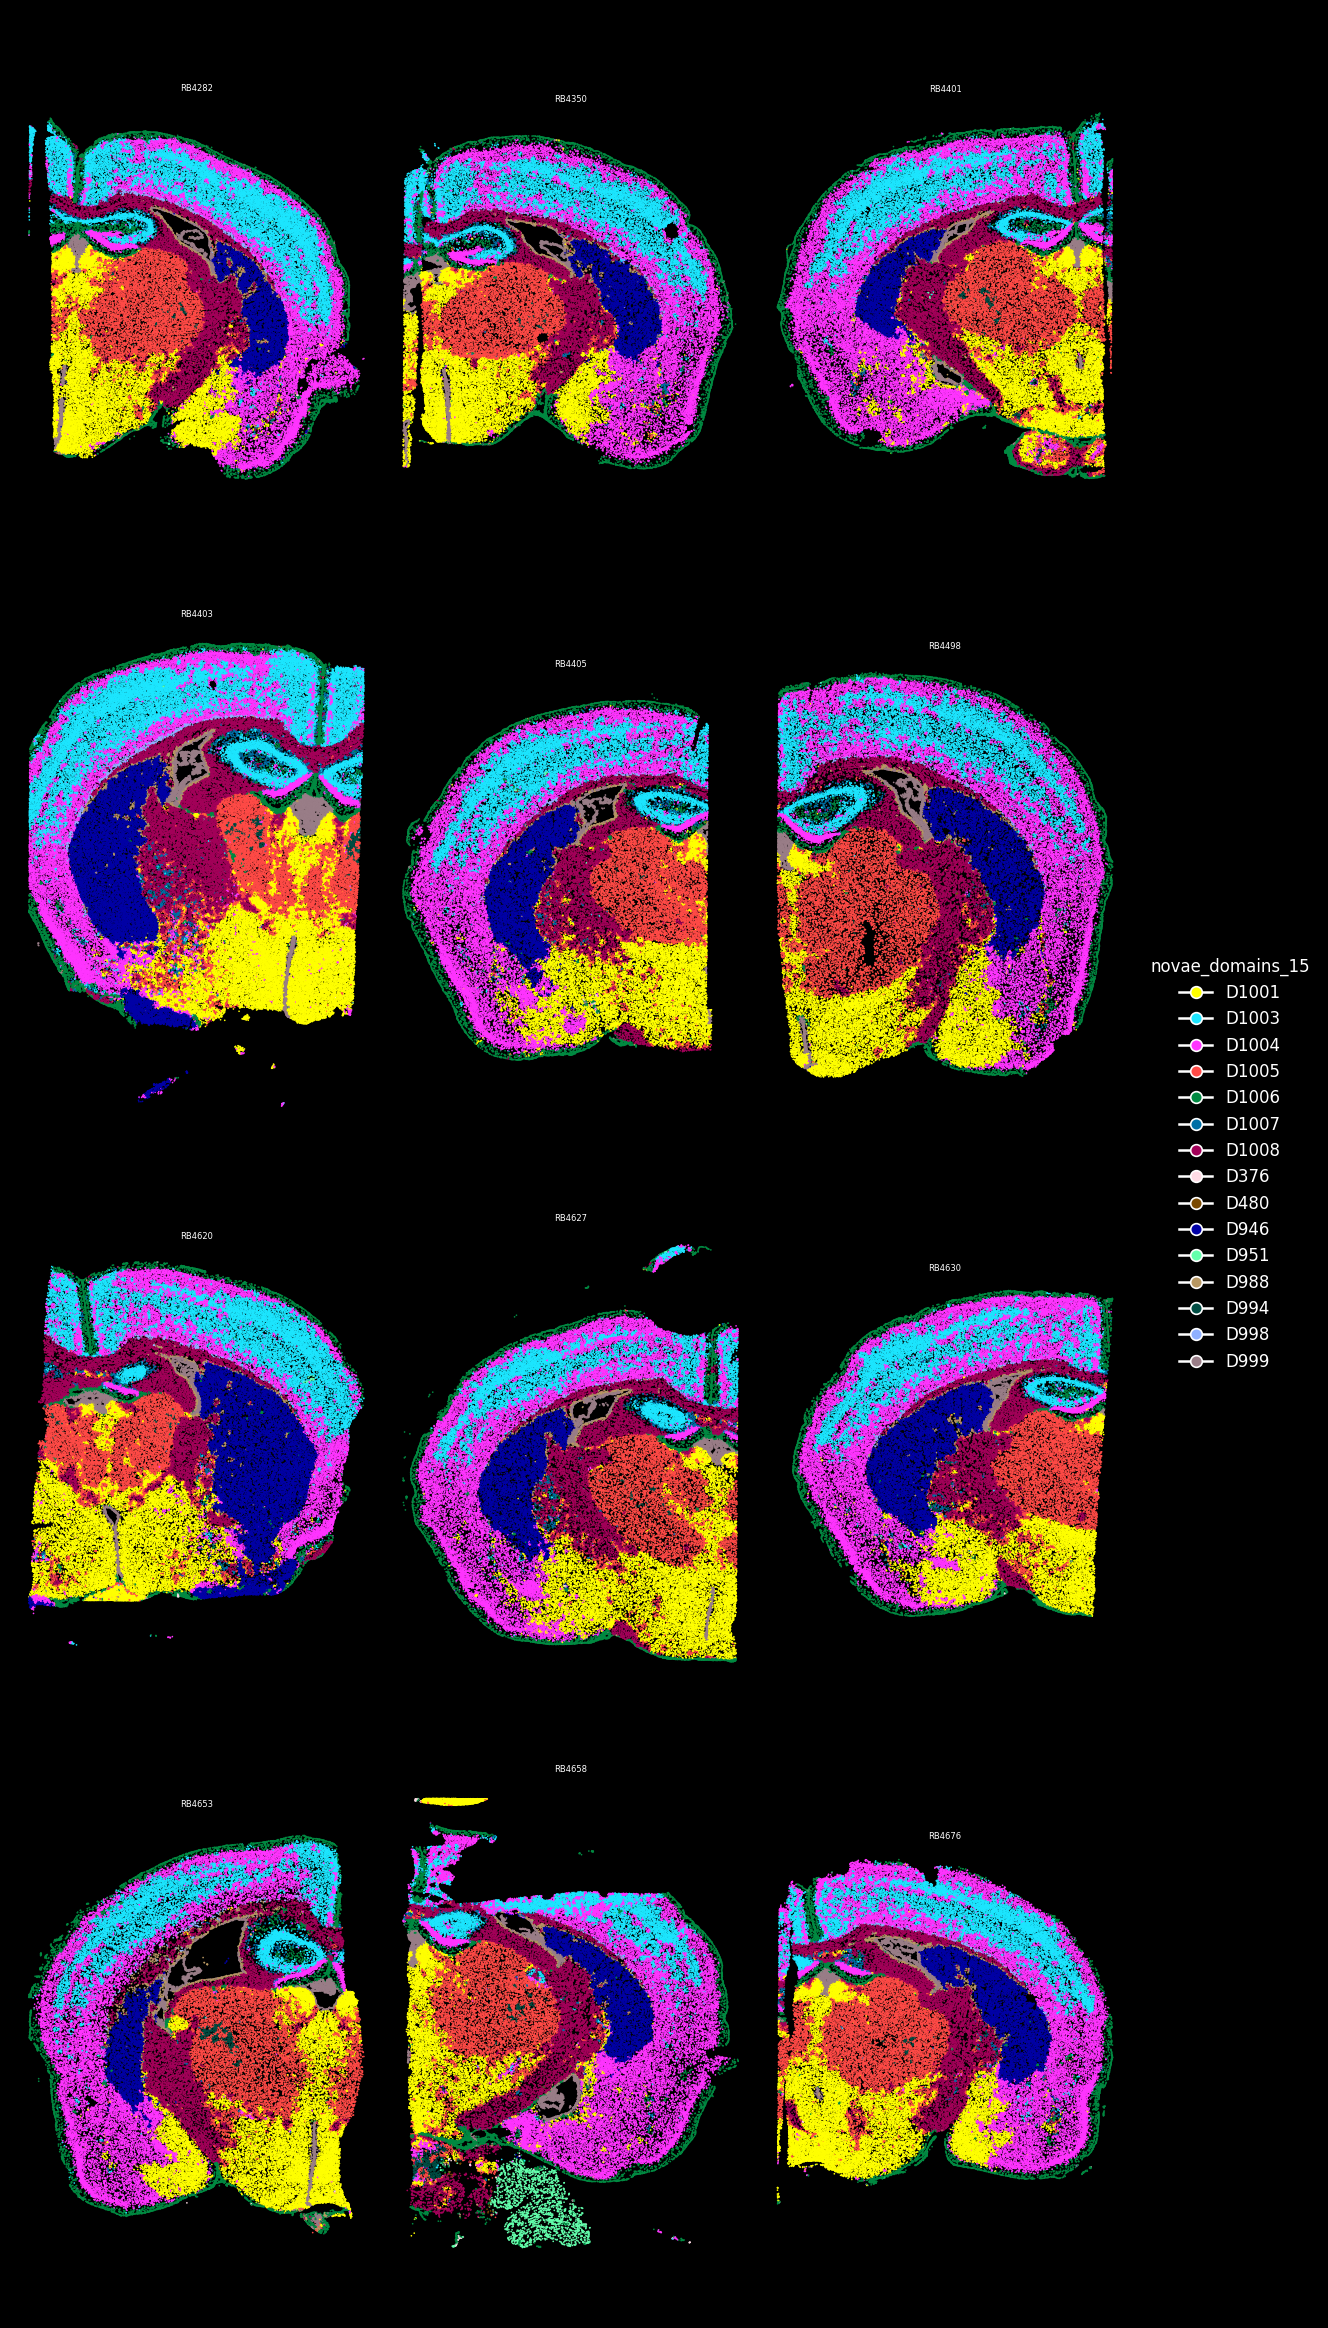

In [17]:
# usage
spatial_utils.plot_spatial_compact_fast(
    ad,
    color="novae_domains_15",
    groupby="sample_id",
    spot_size=1,
    cols=3,
    height=20,
    legend_col_width=1.0,
    background="black",
    grey_alpha=0.05,invert_y = False

)